# Session 27: Convolutional Neural Networks with PyTorch
### Duration: ~2.5-3 Hours

---

## Session Goal
In Session 26, we classified images by flattening each image:

```text
8 x 8 image -> 64 numbers -> neural network
```

That worked, but flattening removes the image structure.

In this session, we learn **Convolutional Neural Networks**, usually called **CNNs**.

CNNs are designed for image data because they look at nearby pixels together.

## What Students Will Learn
- Why normal dense neural networks are limited for images
- What convolution means
- What filters/kernels do
- What feature maps are
- What pooling does
- How image tensors are shaped in PyTorch
- How to build a small CNN using PyTorch
- How to train and evaluate a CNN
- How to inspect predictions and feature maps

## Dataset
We continue with scikit-learn's built-in **Digits dataset**.

Each image is:

```text
8 x 8 grayscale image
```

The target is:

```text
digit 0 to 9
```

This keeps the focus on CNN ideas instead of large datasets or long training time.

---
## 1. Why CNNs?

A normal dense neural network treats an image as a long list of numbers.

Example:

```text
8 x 8 image -> 64 values
```

Problem:

```text
The model no longer directly knows which pixels are neighbors.
```

But in images, nearby pixels matter.

A CNN keeps the image as a grid and learns local visual patterns:

```text
edges -> curves -> shapes -> objects
```

For handwritten digits, CNNs can learn patterns like:

```text
vertical stroke
horizontal stroke
loop
curve
corner
```

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_digits
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

OUTPUT_DIR = Path('session27_artifacts')
OUTPUT_DIR.mkdir(exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch version:', torch.__version__)
print('Using device:', DEVICE)

PyTorch version: 2.12.0+cpu
Using device: cpu


---
## 2. Load the Digits Images

We use the same dataset as Session 26 so students can compare the idea:

Session 26:

```text
flatten image -> MLP
```

Session 27:

```text
keep image grid -> CNN
```

In [2]:
digits = load_digits()
images = digits.images.astype('float32')
y = digits.target.astype('int64')
class_names = [str(i) for i in digits.target_names]

print('Images shape:', images.shape)
print('Target shape:', y.shape)
print('Pixel value range:', images.min(), 'to', images.max())
print('Classes:', class_names)

Images shape: (1797, 8, 8)
Target shape: (1797,)
Pixel value range: 0.0 to 16.0
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


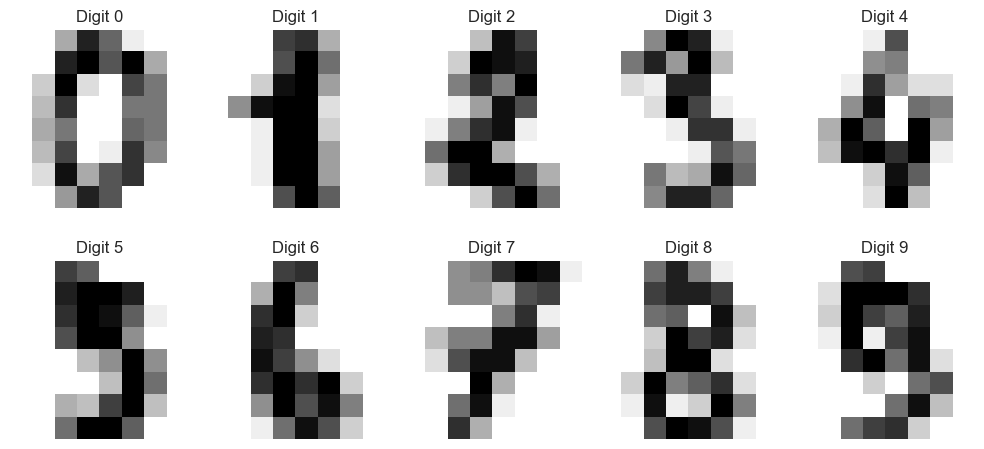

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

for digit in range(10):
    index = np.where(y == digit)[0][0]
    axes[digit].imshow(images[index], cmap='gray_r')
    axes[digit].set_title(f'Digit {digit}')
    axes[digit].axis('off')

plt.tight_layout()
plt.show()

---
## 3. Image Shape in PyTorch

PyTorch CNN layers expect image tensors in this order:

```text
[number_of_images, channels, height, width]
```

For this dataset:

```text
number_of_images = 1797
channels = 1 because images are grayscale
height = 8
width = 8
```

So we convert:

```text
(1797, 8, 8) -> (1797, 1, 8, 8)
```

We also normalize pixel values:

```text
0 to 16 -> 0 to 1
```

In [4]:
X_images = images / 16.0
X_images = X_images[:, np.newaxis, :, :]

print('CNN input shape:', X_images.shape)
print('New pixel value range:', X_images.min(), 'to', X_images.max())

CNN input shape: (1797, 1, 8, 8)
New pixel value range: 0.0 to 1.0


---
## 4. Convolution Intuition

A convolution uses a small matrix called a **filter** or **kernel**.

The filter slides across the image and calculates a new value at each location.

Different filters detect different visual patterns.

Examples:

```text
Vertical edge filter
Horizontal edge filter
Blur filter
```

Let us manually apply simple filters using NumPy before using PyTorch.

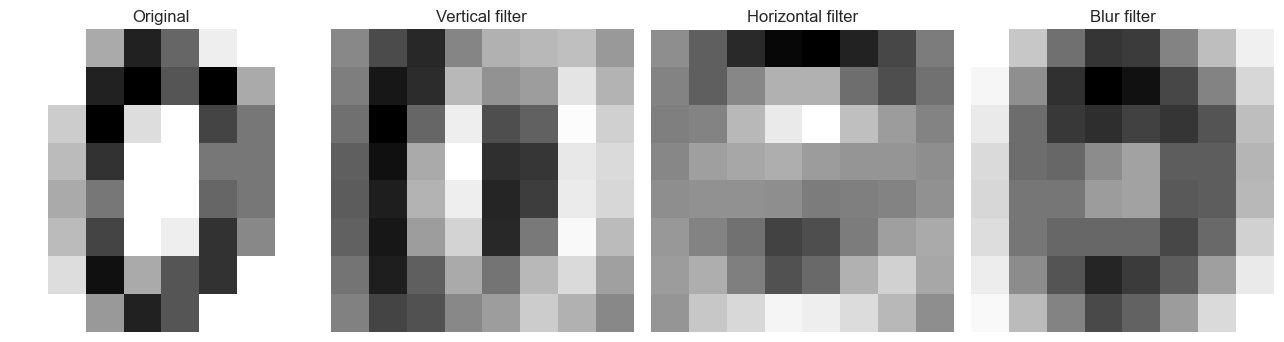

In [5]:
def convolve2d(image, kernel):
    kernel_height, kernel_width = kernel.shape
    pad_h = kernel_height // 2
    pad_w = kernel_width // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(image, dtype='float32')

    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            region = padded[row:row + kernel_height, col:col + kernel_width]
            output[row, col] = np.sum(region * kernel)

    return output

sample_digit = 0
sample_index = np.where(y == sample_digit)[0][0]
sample_image = images[sample_index] / 16.0

vertical_filter = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
], dtype='float32')

horizontal_filter = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1],
], dtype='float32')

blur_filter = np.ones((3, 3), dtype='float32') / 9

filtered_images = {
    'Original': sample_image,
    'Vertical filter': convolve2d(sample_image, vertical_filter),
    'Horizontal filter': convolve2d(sample_image, horizontal_filter),
    'Blur filter': convolve2d(sample_image, blur_filter),
}

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, (title, image) in zip(axes, filtered_images.items()):
    ax.imshow(image, cmap='gray_r')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 5. CNN Building Blocks

A basic CNN often uses these layers:

### Convolution Layer
Learns filters that detect local patterns.

```text
nn.Conv2d(...)
```

### ReLU Activation
Keeps useful positive signals and adds non-linearity.

```text
nn.ReLU()
```

### Pooling Layer
Reduces image size while keeping important information.

```text
nn.MaxPool2d(...)
```

### Flatten Layer
Converts feature maps into a vector.

```text
nn.Flatten()
```

### Linear Layer
Final dense layer for classification.

```text
nn.Linear(...)
```

Simple CNN flow:

```text
Image -> Convolution -> ReLU -> Pooling -> Flatten -> Dense Output
```

---
## 6. Train-Test Split and DataLoaders

PyTorch commonly trains models using `Dataset` and `DataLoader`.

A `DataLoader` gives data to the model in small groups called **batches**.

Batch training is useful because neural networks do not usually process the entire dataset at once.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_images,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print('Training tensor shape:', X_train_tensor.shape)
print('Test tensor shape:', X_test_tensor.shape)
print('Number of training batches:', len(train_loader))
print('Number of test batches:', len(test_loader))

Training tensor shape: torch.Size([1347, 1, 8, 8])
Test tensor shape: torch.Size([450, 1, 8, 8])
Number of training batches: 43
Number of test batches: 4


---
## 7. Build a Small CNN in PyTorch

We define a CNN by creating a class that inherits from `nn.Module`.

The model has:

```text
Conv2d: 1 input channel -> 8 feature maps
ReLU
MaxPool2d: 8x8 -> 4x4
Conv2d: 8 feature maps -> 16 feature maps
ReLU
Flatten
Linear layers for classification
```

Because the image becomes `16 x 4 x 4` before flattening, the first dense layer receives:

```text
16 * 4 * 4 = 256 values
```

In [7]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 4 * 4, 32),
            nn.ReLU(),
            nn.Linear(32, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SmallCNN().to(DEVICE)
print(model)

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)


---
## 8. Understand Model Output Shape

The model outputs raw class scores called **logits**.

For one batch:

```text
input shape: [batch_size, 1, 8, 8]
output shape: [batch_size, 10]
```

There are 10 output scores because there are 10 digit classes.

In [8]:
example_batch, example_labels = next(iter(train_loader))
example_batch = example_batch.to(DEVICE)

with torch.no_grad():
    example_outputs = model(example_batch)

print('Input batch shape:', example_batch.shape)
print('Output batch shape:', example_outputs.shape)
print('First image raw class scores:')
print(example_outputs[0].cpu().numpy().round(3))

Input batch shape: torch.Size([32, 1, 8, 8])
Output batch shape: torch.Size([32, 10])
First image raw class scores:
[ 0.064 -0.165 -0.071 -0.075  0.175 -0.058 -0.158 -0.057  0.004  0.094]


---
## 9. Loss Function and Optimizer

For multi-class classification, we use:

```text
CrossEntropyLoss
```

This compares the model's class scores with the correct digit label.

For updating weights, we use:

```text
Adam optimizer
```

The optimizer adjusts weights to reduce loss.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print('Loss function:', criterion)
print('Optimizer:', optimizer.__class__.__name__)

Loss function: CrossEntropyLoss()
Optimizer: Adam


---
## 10. Train the CNN

Training loop steps:

```text
1. Send batch to device
2. Make predictions
3. Calculate loss
4. Clear old gradients
5. Backpropagate
6. Update weights
7. Track accuracy
```

In [22]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_images, batch_labels in data_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_images)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == batch_labels).sum().item()
        total += batch_labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch_images, batch_labels in data_loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_images)
            loss = criterion(outputs, batch_labels)

            total_loss += loss.item() * batch_images.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == batch_labels).sum().item()
            total += batch_labels.size(0)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    return total_loss / total, correct / total, np.array(all_predictions), np.array(all_labels)

history = []
EPOCHS = 25

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, DEVICE)

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_accuracy': train_acc,
        'test_loss': test_loss,
        'test_accuracy': test_acc,
    })

    if epoch == 1 or epoch % 5 == 0:
        print(
            f'Epoch {epoch:02d} | '
            f'Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | '
            f'Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}'
        )

history_df = pd.DataFrame(history)
history_df.tail()

Epoch 01 | Train loss: 0.0160 | Train acc: 0.9985 | Test loss: 0.1324 | Test acc: 0.9644
Epoch 05 | Train loss: 0.0139 | Train acc: 0.9993 | Test loss: 0.1149 | Test acc: 0.9689
Epoch 10 | Train loss: 0.0096 | Train acc: 0.9993 | Test loss: 0.1203 | Test acc: 0.9711
Epoch 15 | Train loss: 0.0069 | Train acc: 1.0000 | Test loss: 0.1176 | Test acc: 0.9756
Epoch 20 | Train loss: 0.0074 | Train acc: 1.0000 | Test loss: 0.1267 | Test acc: 0.9778
Epoch 25 | Train loss: 0.0040 | Train acc: 1.0000 | Test loss: 0.1208 | Test acc: 0.9733


,epoch,train_loss,train_accuracy,test_loss,test_accuracy
20,21,0.005762,1.0,0.123020,0.971111
21,22,0.004817,1.0,0.122062,0.966667
22,23,0.004501,1.0,0.116616,0.973333
23,24,0.004271,1.0,0.122387,0.971111
24,25,0.004039,1.0,0.120844,0.973333


---
## 11. Plot Training History

A good training curve usually shows:

```text
loss going down
accuracy going up
```

If training accuracy is high but test accuracy is low, the model may be overfitting.

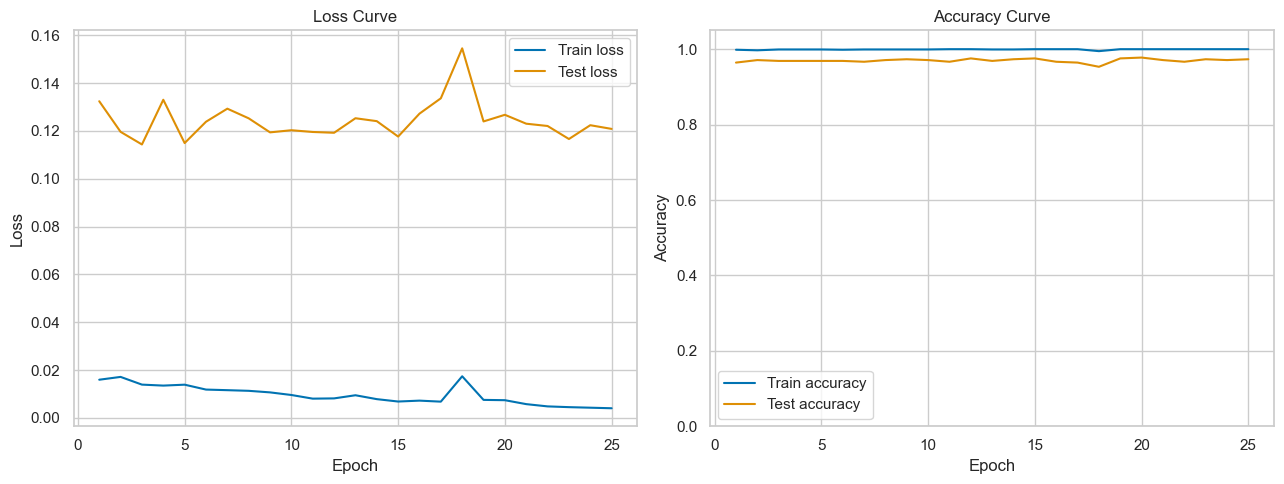

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train loss')
axes[0].plot(history_df['epoch'], history_df['test_loss'], label='Test loss')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_accuracy'], label='Train accuracy')
axes[1].plot(history_df['epoch'], history_df['test_accuracy'], label='Test accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 12. Evaluate the Final CNN

Now we evaluate the model on test data.

In [24]:
test_loss, test_accuracy, cnn_predictions, y_test_array = evaluate(model, test_loader, criterion, DEVICE)

print('Final test loss:', round(test_loss, 4))
print('Final test accuracy:', round(test_accuracy, 4))
print('\nClassification report:')
print(classification_report(y_test_array, cnn_predictions, target_names=class_names))

Final test loss: 0.1208
Final test accuracy: 0.9733

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        45
           1       0.96      0.98      0.97        46
           2       1.00      0.98      0.99        44
           3       0.98      1.00      0.99        46
           4       0.96      0.98      0.97        45
           5       0.98      0.98      0.98        46
           6       0.98      0.98      0.98        45
           7       0.98      1.00      0.99        45
           8       0.95      0.91      0.93        43
           9       0.98      0.98      0.98        45

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450



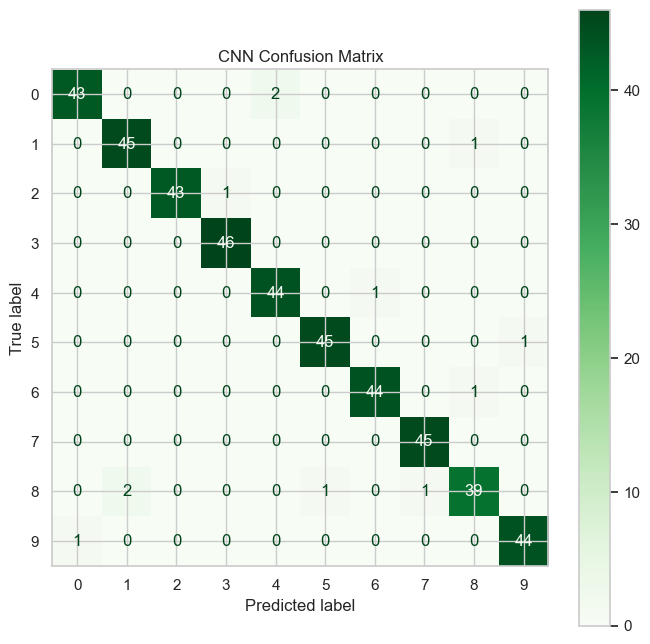

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test_array,
    cnn_predictions,
    display_labels=class_names,
    cmap='Greens',
    ax=ax,
)
plt.title('CNN Confusion Matrix')
plt.show()

---
## 13. View Predictions

Green titles mean correct predictions.
Red titles mean incorrect predictions.

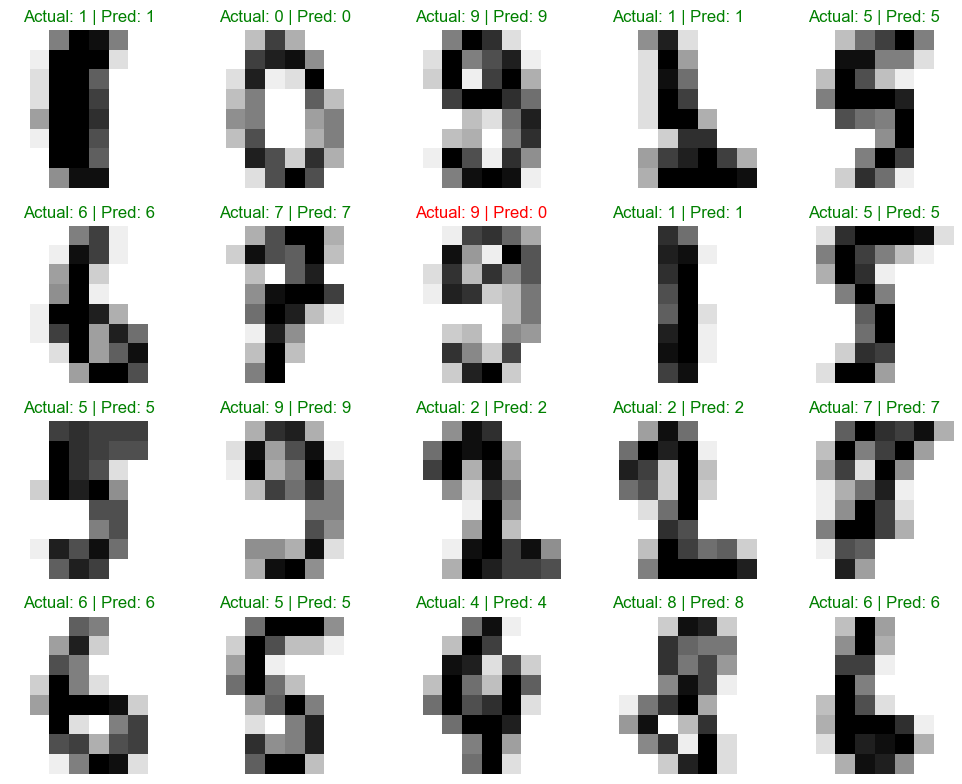

In [26]:
# Recreate the test image grids in the same split order.
_, test_images_grid, _, test_labels_grid = train_test_split(
    images,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

fig, axes = plt.subplots(4, 5, figsize=(10, 8))
axes = axes.ravel()

for ax, image, actual, pred in zip(axes, test_images_grid[:20], test_labels_grid[:20], cnn_predictions[:20]):
    ax.imshow(image, cmap='gray_r')
    color = 'green' if actual == pred else 'red'
    ax.set_title(f'Actual: {actual} | Pred: {pred}', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 14. Inspect Wrong Predictions

Wrong predictions are not failures of the lesson.

They are useful because they show where the model is uncertain or where handwriting is confusing.

Number of wrong predictions: 12


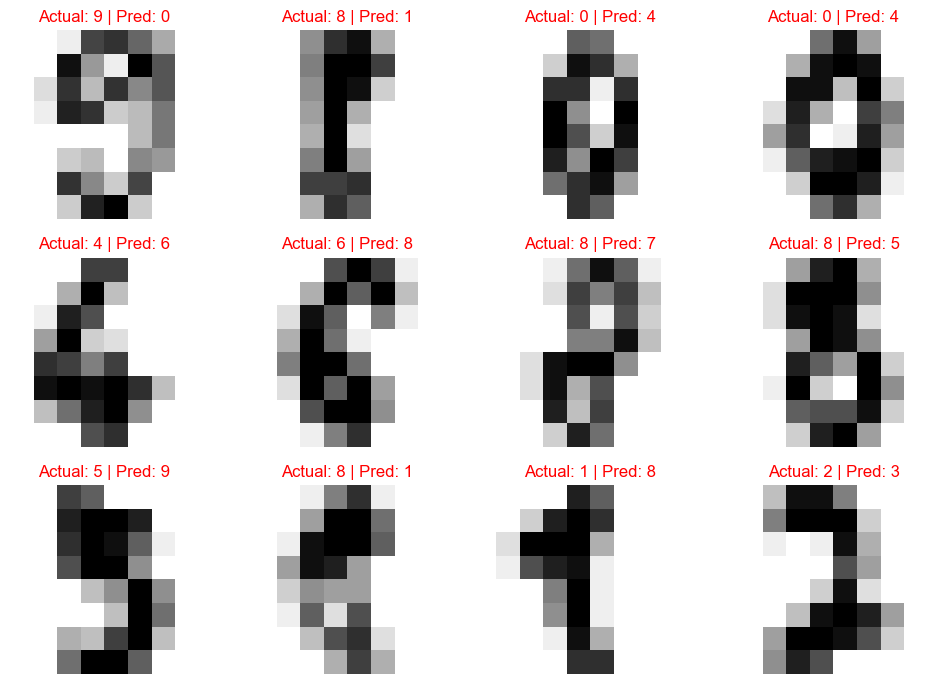

In [27]:
wrong_indices = np.where(cnn_predictions != y_test_array)[0]
print('Number of wrong predictions:', len(wrong_indices))

if len(wrong_indices) > 0:
    n_show = min(12, len(wrong_indices))
    fig, axes = plt.subplots(3, 4, figsize=(10, 7))
    axes = axes.ravel()

    for ax, index in zip(axes, wrong_indices[:n_show]):
        ax.imshow(test_images_grid[index], cmap='gray_r')
        ax.set_title(f'Actual: {y_test_array[index]} | Pred: {cnn_predictions[index]}', color='red')
        ax.axis('off')

    for ax in axes[n_show:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('No wrong predictions on this test split.')

---
## 15. Prediction Probabilities

The CNN outputs logits.

To convert logits into probabilities, we use softmax.

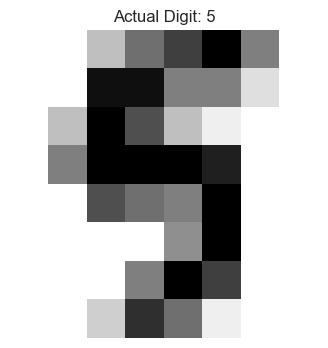

,digit,probability
5,5,1.0
9,9,0.0
8,8,0.0
4,4,0.0
1,1,0.0
6,6,0.0
7,7,0.0
3,3,0.0
0,0,0.0
2,2,0.0


In [28]:
example_index = 4
example_tensor = X_test_tensor[example_index:example_index + 1].to(DEVICE)

model.eval()
with torch.no_grad():
    logits = model(example_tensor)
    probabilities = torch.softmax(logits, dim=1).cpu().numpy()[0]

prob_table = pd.DataFrame({
    'digit': class_names,
    'probability': probabilities,
}).sort_values('probability', ascending=False)

plt.figure(figsize=(4, 4))
plt.imshow(test_images_grid[example_index], cmap='gray_r')
plt.title(f'Actual Digit: {y_test_array[example_index]}')
plt.axis('off')
plt.show()

prob_table.round(4)

---
## 16. Visualize Learned Filters

The first convolution layer learns filters.

Because the input has one grayscale channel, each first-layer filter is a small 3 x 3 matrix.

These learned filters detect simple local patterns.

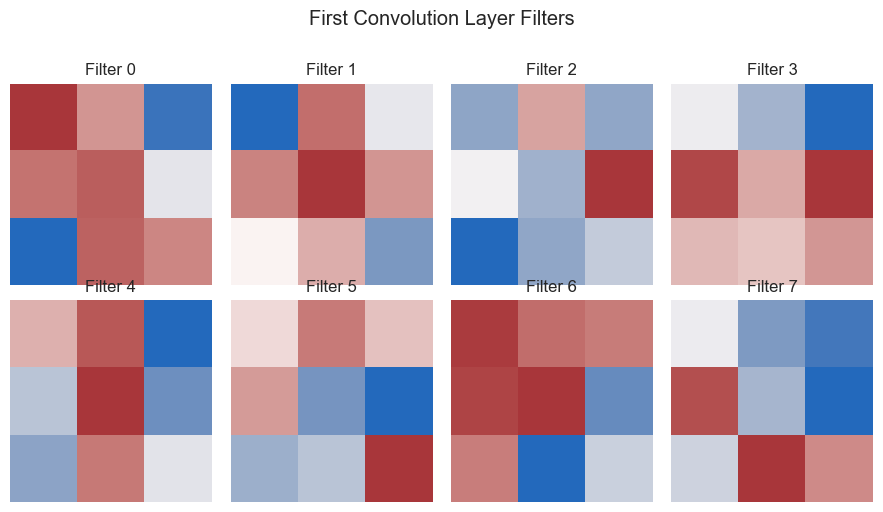

In [29]:
first_conv = model.features[0]
filters = first_conv.weight.detach().cpu().numpy()

fig, axes = plt.subplots(2, 4, figsize=(9, 5))
axes = axes.ravel()

for i, ax in enumerate(axes):
    ax.imshow(filters[i, 0], cmap='vlag')
    ax.set_title(f'Filter {i}')
    ax.axis('off')

plt.suptitle('First Convolution Layer Filters', y=1.02)
plt.tight_layout()
plt.show()

---
## 17. Visualize Feature Maps

A feature map is the result of applying a filter to an image.

Different filters activate on different patterns.

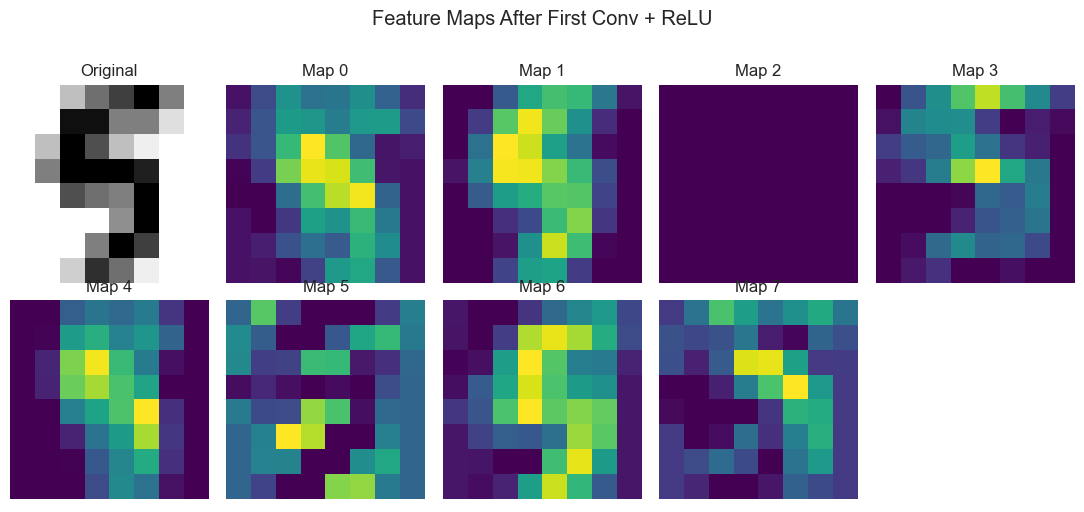

In [30]:
feature_extractor = nn.Sequential(*list(model.features.children())[:2]).to(DEVICE)
feature_extractor.eval()

sample_tensor = X_test_tensor[example_index:example_index + 1].to(DEVICE)

with torch.no_grad():
    feature_maps = feature_extractor(sample_tensor).cpu().numpy()[0]

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
axes = axes.ravel()

axes[0].imshow(test_images_grid[example_index], cmap='gray_r')
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(8):
    axes[i + 1].imshow(feature_maps[i], cmap='viridis')
    axes[i + 1].set_title(f'Map {i}')
    axes[i + 1].axis('off')

axes[-1].axis('off')
plt.suptitle('Feature Maps After First Conv + ReLU', y=1.02)
plt.tight_layout()
plt.show()

---
## 18. Compare Session 26 and Session 27

Session 26 used a basic neural network:

```text
Flatten image -> Dense layers
```

Session 27 used a CNN:

```text
Image grid -> Convolution -> Pooling -> Dense layers
```

The key improvement is that CNNs learn local image patterns before making the final classification.

CNNs are especially useful when images are larger and more complex.

In [31]:
summary = pd.DataFrame({
    'approach': ['Session 26 MLP idea', 'Session 27 CNN'],
    'input_handling': ['Flatten image into pixel list', 'Keep image as channel-height-width grid'],
    'main_strength': ['Simple and easy to understand', 'Learns local visual patterns'],
    'best_for': ['Small/simple image problems', 'Larger and more realistic image problems'],
})

summary

,approach,input_handling,main_strength,best_for
0,Session 26 MLP idea,Flatten image into pixel list,Simple and easy to understand,Small/simple image problems
1,Session 27 CNN,Keep image as channel-height-width grid,Learns local visual patterns,Larger and more realistic image problems


---
## 19. Save the CNN and Artifacts

PyTorch models are commonly saved using `torch.save`.

We save:

- model weights
- training history
- prediction probabilities for one example
- comparison summary

In [32]:
model_path = OUTPUT_DIR / 'digits_cnn_pytorch_state_dict.pt'
history_path = OUTPUT_DIR / 'cnn_training_history.csv'
probability_path = OUTPUT_DIR / 'cnn_example_prediction_probabilities.csv'
summary_path = OUTPUT_DIR / 'session26_vs_session27_summary.csv'

# Save only learned weights. To reuse, recreate SmallCNN and load this state dict.
torch.save(model.state_dict(), model_path)
history_df.to_csv(history_path, index=False)
prob_table.to_csv(probability_path, index=False)
summary.to_csv(summary_path, index=False)

print('Saved PyTorch model weights:', model_path)
print('Saved training history:', history_path)
print('Saved prediction probabilities:', probability_path)
print('Saved comparison summary:', summary_path)

Saved PyTorch model weights: session27_artifacts\digits_cnn_pytorch_state_dict.pt
Saved training history: session27_artifacts\cnn_training_history.csv
Saved prediction probabilities: session27_artifacts\cnn_example_prediction_probabilities.csv
Saved comparison summary: session27_artifacts\session26_vs_session27_summary.csv


---
## 20. Class Discussion Questions

Use these questions to check understanding:

1. Why is flattening an image limited?
2. What is a convolution filter?
3. What is a feature map?
4. Why do CNNs work well for images?
5. What does pooling do?
6. Why does PyTorch use `[batch, channels, height, width]`?
7. What is the difference between logits and probabilities?
8. What does `CrossEntropyLoss` do?
9. Why do we use `optimizer.zero_grad()` before backpropagation?
10. What can wrong predictions teach us?

---

## Final Summary

CNNs are neural networks designed for image data.

The main idea:

```text
Learn local image patterns before making a final prediction.
```

Important CNN terms:

```text
Convolution
Filter / Kernel
Feature map
ReLU
Pooling
Flatten
Fully connected layer
```

PyTorch workflow:

```text
Prepare tensors -> Create DataLoader -> Define nn.Module -> Train loop -> Evaluate -> Save weights
```

Next recommended session:

```text
Session 28: Better CNNs and Image Classification with a Larger Dataset
```

or

```text
Session 28: Introduction to Transfer Learning
```